# Phase 6 — Baseline et protocole d'évaluation : carnet de travail

**Rôle de ce carnet.** Avant de chercher un meilleur modèle, il faut savoir contre quoi il se mesurera. Ce
carnet fixe le **protocole d'évaluation**, exécute **trois références** et enregistre leurs résultats dans un
fichier versionné, que la phase 7 devra battre. Les conclusions sont reportées au notebook de certification
(§ 8.D).

**Les trois arbitrages**, fixés le 02/10/2026 **avant** d'exécuter la moindre baseline (règle 8) :

| Arbitrage | Décision |
|---|---|
| Baseline métier | Classer les comptes par ancienneté de la dernière connexion, ce qu'un CSM ferait sans modèle |
| Haut du classement | Les 10 % de comptes les plus risqués, lus en rappel et en précision |
| Calibration | Au-delà d'une erreur moyenne de 0,05, la phase 7 calibre le modèle retenu |

In [1]:
# --- Environment ---------------------------------------------------------------------
import importlib.util
import json
import sys
import time
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas import config
from churn_saas.features import executer_pipeline, parties_du_decoupage
from churn_saas.notebook import afficher_source, afficher_tableau

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
resultat = executer_pipeline(config.FICHIER_COMPLET, config.FICHIER_CATALOGUE)
parties = parties_du_decoupage(resultat)
X, y = parties.X_entrainement, parties.y_entrainement
print(f"Partie d'entraînement : {len(y)} comptes × {X.shape[1]} variables, churn {y.mean():.1%} "
      "— le jeu de test reste sous scellés")

Partie d'entraînement : 4000 comptes × 18 variables, churn 28.0% — le jeu de test reste sous scellés


## 1. Le protocole, écrit avant les résultats

Le protocole est déclaré **comme une donnée** dans `evaluation/protocole.py` : ce qui est mesuré, sur quels
plis, et pourquoi. Tous les modèles du projet seront comparés selon ce même protocole.

In [2]:
# --- The protocol, as the code declares it -----------------------------------------------------
from churn_saas.evaluation import METRIQUES

afficher_tableau(pd.DataFrame([(m.nom, m.role, m.motif) for m in METRIQUES],
                              columns=["Métrique", "Rôle", "Pourquoi"]),
                 titre="Les métriques du protocole")
afficher_tableau(pd.DataFrame([
    ("Plis", f"{config.PLIS_VALIDATION} plis stratifiés × {config.REPETITIONS_VALIDATION} répétitions, graine {config.GRAINE}"),
    ("Partie évaluée", "entraînement seulement ; le test sert une fois, à l'évaluation finale"),
    ("Haut du classement", f"{config.PART_HAUT_CLASSEMENT:.0%} des comptes"),
    ("Seuil de calibration", f"erreur moyenne > {config.SEUIL_ERREUR_CALIBRATION} : la phase 7 calibre"),
    ("Baseline métier", f"classement par `{config.VARIABLE_REGLE_METIER}`"),
], columns=["Paramètre", "Valeur"]), titre="Paramètres du protocole (lus dans la configuration)")

Métrique,Rôle,Pourquoi
PR-AUC,critère principal,insensible au confort des 72 % de clients qui restent
ROC-AUC,"secondaire, exigé par l'énoncé",capacité générale à ordonner les comptes
rappel haut,lecture métier,part des départs trouvés dans les 10% de comptes les plus risqués
précision haut,lecture métier,part de vrais départs parmi ces 10% de comptes
Brier,calibration,écart quadratique entre probabilité annoncée et issue
erreur de calibration,calibration,"écart moyen par tranche de probabilité ; au-delà de 0.05, la phase 7 calibre le modèle retenu"


Paramètre,Valeur
Plis,"5 plis stratifiés × 5 répétitions, graine 42"
Partie évaluée,"entraînement seulement ; le test sert une fois, à l'évaluation finale"
Haut du classement,10% des comptes
Seuil de calibration,erreur moyenne > 0.05 : la phase 7 calibre
Baseline métier,classement par `derniere_connexion_jours`


**Les 25 plis sont ceux de la sélection des variables (phase 5).** Un test le vérifie : les baselines et la
sélection sont mesurées sur exactement les mêmes découpages, ce qui rend leurs chiffres comparables.

**Pourquoi la calibration entre dans le protocole.** La règle de décision classe les comptes par
probabilité × valeur du compte. Si le modèle annonce 60 % là où 40 % des comptes partent réellement, ce
produit est faux, et le classement par valeur aussi — même avec une excellente PR-AUC, qui ne regarde que
l'ordre.

## 2. Trois références

| Référence | Ce qu'elle mesure |
|---|---|
| **Naïve** — le taux de base pour tout le monde | Le plancher : une PR-AUC égale au taux de churn |
| **Règle métier** — classer par ancienneté de la dernière connexion | Ce qu'un CSM ferait sans modèle ; si le modèle ne la bat pas clairement, il ne se justifie pas |
| **Régression logistique** — la baseline du cadrage | La référence que la phase 7 devra battre |

In [3]:
# --- The business rule: no learning, a ranking ------------------------------------------------
from churn_saas.modelisation import RegleMetier

afficher_source(RegleMetier)

**Source — `churn_saas.modelisation.baseline.RegleMetier`**

```python
class RegleMetier(ClassifierMixin, BaseEstimator):
    """Rank accounts by one variable, as a CSM would without a model.

    No learning: `fit` only records the variable's range, so the score lies in [0, 1].
    It is a ranking, not a probability - the protocol reports no calibration for it.
    """

    def __init__(self, colonne: str = "derniere_connexion_jours", croissant: bool = True):
        self.colonne = colonne
        self.croissant = croissant

    def fit(self, X: pd.DataFrame, y: pd.Series) -> RegleMetier:
        valeurs = pd.to_numeric(X[self.colonne], errors="coerce")
        self.minimum_, self.maximum_ = float(valeurs.min()), float(valeurs.max())
        self.mediane_ = float(valeurs.median())
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        valeurs = pd.to_numeric(X[self.colonne], errors="coerce").fillna(self.mediane_)
        etendue = max(self.maximum_ - self.minimum_, 1e-12)
        score = ((valeurs - self.minimum_) / etendue).clip(0, 1).to_numpy()
        score = score if self.croissant else 1 - score
        return np.column_stack([1 - score, score])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

```

'class RegleMetier(ClassifierMixin, BaseEstimator):\n    """Rank accounts by one variable, as a CSM would without a model.\n\n    No learning: `fit` only records the variable\'s range, so the score lies in [0, 1].\n    It is a ranking, not a probability - the protocol reports no calibration for it.\n    """\n\n    def __init__(self, colonne: str = "derniere_connexion_jours", croissant: bool = True):\n        self.colonne = colonne\n        self.croissant = croissant\n\n    def fit(self, X: pd.DataFrame, y: pd.Series) -> RegleMetier:\n        valeurs = pd.to_numeric(X[self.colonne], errors="coerce")\n        self.minimum_, self.maximum_ = float(valeurs.min()), float(valeurs.max())\n        self.mediane_ = float(valeurs.median())\n        self.classes_ = np.array([0, 1])\n        return self\n\n    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:\n        valeurs = pd.to_numeric(X[self.colonne], errors="coerce").fillna(self.mediane_)\n        etendue = max(self.maximum_ - self.min

## 3. Les résultats sur les 25 plis

Calcul des trois baselines sur 25 plis : 2.0 s


référence,PR-AUC,ROC-AUC,rappel haut,précision haut,Brier,erreur de calibration
naïve,0.280 ± 0.000,0.500 ± 0.000,0.102 ± 0.014,0.287 ± 0.040,0.202 ± 0.000,0.000 ± 0.000
règle métier,0.530 ± 0.019,0.674 ± 0.019,0.258 ± 0.011,0.723 ± 0.031,—,—
régression logistique,0.793 ± 0.019,0.892 ± 0.011,0.331 ± 0.007,0.926 ± 0.019,0.133 ± 0.007,0.114 ± 0.012


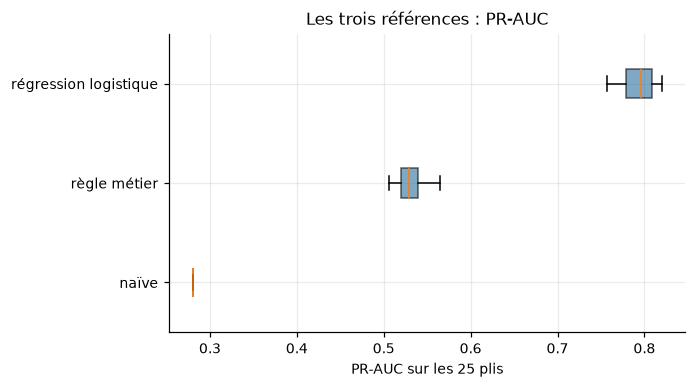

La régression logistique bat la règle métier sur 25 plis sur 25.


In [4]:
# --- The three baselines under the protocol --------------------------------------------------
from churn_saas.evaluation import evaluer_selon_protocole, resumer
from churn_saas.features import tracer_baselines
from churn_saas.modelisation import (construire_baseline, construire_baseline_metier,
                                     construire_baseline_naive)

debut = time.perf_counter()
baselines = {
    "naïve": evaluer_selon_protocole(construire_baseline_naive, X, y),
    "règle métier": evaluer_selon_protocole(construire_baseline_metier, X, y, probabiliste=False),
    "régression logistique": evaluer_selon_protocole(construire_baseline, X, y),
}
print(f"Calcul des trois baselines sur 25 plis : {time.perf_counter() - debut:.1f} s")
afficher_tableau(resumer(baselines).reset_index(names="référence"),
                 titre="Moyenne ± écart-type sur les 25 plis")
tracer_baselines({n: r.par_pli for n, r in baselines.items()})
plt.show()
gagnes = (baselines["régression logistique"].par_pli["PR-AUC"]
          > baselines["règle métier"].par_pli["PR-AUC"]).sum()
print(f"La régression logistique bat la règle métier sur {gagnes} plis sur 25.")

**Lecture.**
- La **règle métier** fait nettement mieux que le hasard (PR-AUC 0,53 contre 0,28) : la dernière connexion
  est un vrai signal, et un CSM qui s'y fierait ne travaillerait pas à l'aveugle.
- La **régression logistique** la dépasse largement (0,79), **sur chacun des 25 plis** : combiner les
  variables apporte bien plus que la meilleure d'entre elles seule. C'est la réponse à la question « pourquoi
  un modèle plutôt qu'une règle ? ».
- **Dans les 10 % de comptes les plus risqués**, plus de 9 signalements sur 10 sont de vrais départs, et un
  tiers des départs y figure. Le rappel ne peut pas dépasser 0,36 à cette coupure (il y a plus de départs que
  de places) : le modèle en est proche.

## 4. Courbes précision-rappel et ROC

Tracées à partir des prédictions **hors pli** de la première répétition : chaque compte est prédit par un
modèle qui ne l'a pas vu.

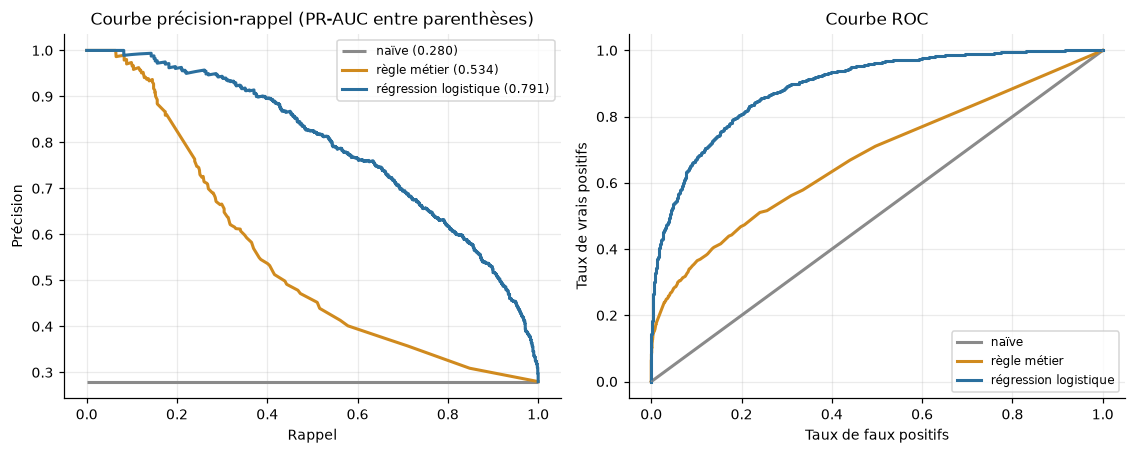

In [5]:
# --- PR and ROC curves from out-of-fold predictions ---------------------------------------------
from churn_saas.features import tracer_courbes_pr_roc

tracer_courbes_pr_roc({nom: (y, r.hors_pli) for nom, r in baselines.items()})
plt.show()

**Lecture.** La courbe de la régression logistique domine celle de la règle métier sur toute la plage : à
rappel égal, elle signale moins de faux départs. La baseline naïve est une ligne horizontale au niveau du taux
de base — c'est ce que vaut un tri au hasard.

## 5. La calibration

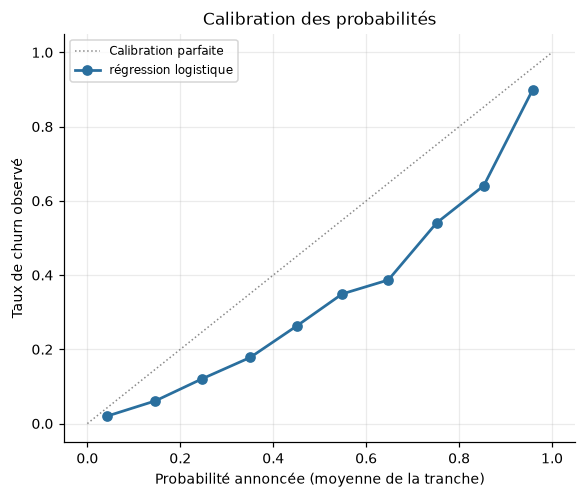

Erreur de calibration (hors pli) : 0.115 — seuil : 0.05 → calibration requise en phase 7


In [6]:
# --- Calibration of the logistic regression ------------------------------------------------------
from churn_saas.evaluation import erreur_calibration
from churn_saas.features import tracer_calibration

lr = baselines["régression logistique"]
tracer_calibration({"régression logistique": (y, lr.hors_pli)})
plt.show()
erreur = erreur_calibration(y, lr.hors_pli)
print(f"Erreur de calibration (hors pli) : {erreur:.3f} — seuil : {config.SEUIL_ERREUR_CALIBRATION} "
      f"→ {'calibration requise en phase 7' if erreur > config.SEUIL_ERREUR_CALIBRATION else 'conforme'}")

**Lecture.** Les points se situent **sous la diagonale** : la régression logistique annonce des probabilités
plus élevées que les taux de départ observés. C'est la conséquence attendue de la **pondération des classes**
(`class_weight="balanced"`) : elle aide le modèle à ordonner les comptes en donnant plus de poids aux départs,
mais elle gonfle les probabilités. L'erreur moyenne (≈ 0,11) dépasse le seuil de 0,05 fixé d'avance : **la phase
7 calibrera le modèle retenu** avant que ses probabilités ne soient multipliées par la valeur des comptes.

## 6. Les résultats de référence, enregistrés

Les scores des trois baselines, pli par pli, sont écrits dans `resultats/reference_baseline.json`, avec le
protocole et l'empreinte du jeu gold sur lequel ils ont été obtenus. La phase 7 se comparera à cette référence
**figée**, et non à un chiffre recalculé à la volée — sinon une régression dans la chaîne déplacerait les deux
termes de la comparaison à la fois, sans que personne ne le voie.

In [7]:
# --- The recorded reference, and the proof the code still reproduces it -------------------------
specification = importlib.util.spec_from_file_location(
    "resultats_reference", RACINE / "tools" / "resultats_reference.py")
outil = importlib.util.module_from_spec(specification)
specification.loader.exec_module(outil)

reference = json.loads((RACINE / "resultats" / "reference_baseline.json").read_text(encoding="utf-8"))
afficher_tableau(pd.DataFrame({n: b["moyenne"] for n, b in reference["baselines"].items()}).T.round(3)
                 .reset_index(names="référence"), titre="Référence enregistrée (moyennes)")
differences = outil.ecarts(reference, outil.calculer())
print("Référence reproduite par le code actuel." if not differences else "\n".join(differences))

référence,PR-AUC,ROC-AUC,rappel haut,précision haut,Brier,erreur de calibration
naïve,0.280,0.500,0.102,0.286,0.202,0.000
règle métier,0.530,0.674,0.258,0.722,NaN,NaN
régression logistique,0.793,0.892,0.331,0.926,0.133,0.114


Référence reproduite par le code actuel.


## 7. Journal de bord de la phase 6

**Décisions.**
- Protocole écrit en code avant tout résultat : 25 plis partagés avec la phase 5, PR-AUC comme critère
  principal, lecture métier au haut du classement, calibration mesurée.
- Trois références plutôt qu'une, dont une **règle métier** : le modèle doit prouver qu'il vaut mieux que ce
  qu'un CSM ferait seul.
- Résultats de référence enregistrés dans un fichier versionné, vérifié par un test.

**Constats.**
- La régression logistique bat la règle métier sur les 25 plis (0,79 contre 0,53 de PR-AUC).
- Elle est **mal calibrée** (≈ 0,11) à cause de la pondération des classes : la phase 7 devra la calibrer.

**Tests de la phase** (règle 14) : campagne `phase6`. Les tests courants couvrent le protocole, les baselines,
l'outil de référence et les figures ; la non-régression ajoute la reproduction de la référence, l'ordre des trois
baselines et le besoin de calibration, et garde les tests unitaires de la phase 5 (`-m phase5`).

**Prochaine étape — phase 7.** Régler la forêt aléatoire, qui sur-apprend, la comparer à la régression
logistique selon ce protocole et contre cette référence, calibrer le modèle retenu, puis l'évaluer une seule
fois sur le jeu de test.